# Exploratory Data Analysis (EDA) - Tech Salaries in India

## Project Objective
Perform exploratory data analysis on the tech salary dataset after applying the standardized cleaning and imputation pipeline. We explore salary distributions, career growth patterns, city indexes, and standard skills frequency.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
# Load the dirty dataset
df = pd.read_csv('https://raw.githubusercontent.com/goyashek/Tech-Salary-Advisor/refs/heads/main/data/salary_dataset_dirty.csv')
df.head()

,Job_Title,Experience_Years,Education_Level,Location,Skills,Salary_INR
0,AI Researcher,1.2,NaN,noida,"Python,JavaScript,SQL,Spark,Docker,TensorFlow",2159338.0
1,QA,4.3,phd,Noida,"Java, JavaScript, Go, Docker, Kubernetes, Tens...",1084669.0
2,backend engineer,3.6,M.S.,NaN,"Python,JavaScript,System Design,Agile",1040748.0
3,data scientist,0.5,PhD,Bangalore,"Python, Java, SQL, AWS, React",1939103.0
4,cv engineer,3.9,masters,Noida,"Python, C++, SQL, PyTorch, React, Agile",1723630.0


## 3. Data Cleaning (Same as Main Pipeline)

In [3]:
# 1. Drop rows where target variable is missing
df = df.dropna(subset=['Salary_INR'])

# 2. Impute missing features with median/mode
exp_median = df['Experience_Years'].median()
df['Experience_Years'] = df['Experience_Years'].fillna(exp_median)
df['Education_Level'] = df['Education_Level'].fillna(df['Education_Level'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Skills'] = df['Skills'].fillna('Python, SQL')

print("Missing values handled successfully!")

Missing values handled successfully!


In [4]:
# 3. Standardize categorical strings
def clean_job_title(title):
    title = str(title).strip().lower()
    if 'data scientist' in title:
        return 'Data Scientist'
    elif 'ml engineer' in title or 'machine learning' in title or 'ai engineer' in title:
        return 'Machine Learning Engineer'
    elif 'ai researcher' in title:
        return 'AI Researcher'
    elif 'nlp' in title:
        return 'NLP Engineer'
    elif 'cv engineer' in title or 'computer vision' in title:
        return 'Computer Vision Engineer'
    elif 'dl engineer' in title or 'deep learning' in title:
        return 'Deep Learning Engineer'
    elif 'frontend' in title:
        return 'Frontend Developer'
    elif 'backend' in title:
        return 'Backend Developer'
    elif 'fullstack' in title or 'full stack' in title:
        return 'Full Stack Developer'
    elif 'devops' in title:
        return 'DevOps Engineer'
    elif 'data engineer' in title:
        return 'Data Engineer'
    elif 'qa' in title:
        return 'QA Engineer'
    elif 'product' in title or 'pm' in title:
        return 'Product Manager'
    else:
        return 'Software Engineer'

def clean_location(city):
    city = str(city).strip().lower()
    if 'bangalore' in city:
        return 'Bangalore'
    elif 'mumbai' in city:
        return 'Mumbai'
    elif 'delhi' in city:
        return 'Delhi NCR'
    elif 'noida' in city:
        return 'Noida'
    elif 'hyderabad' in city:
        return 'Hyderabad'
    elif 'pune' in city:
        return 'Pune'
    elif 'chennai' in city:
        return 'Chennai'
    else:
        return 'Bangalore'

def clean_education(edu):
    edu = str(edu).strip().lower()
    if 'master' in edu or 'mtech' in edu or 'm.tech' in edu or 'ms' in edu or 'm.s.' in edu:
        return "Master's"
    elif 'phd' in edu or 'doctor' in edu:
        return 'PhD'
    else:
        return "Bachelor's"

df['Job_Title'] = df['Job_Title'].apply(clean_job_title)
df['Location'] = df['Location'].apply(clean_location)
df['Education_Level'] = df['Education_Level'].apply(clean_education)

# Create Salary in LPA column for ease of plotting
df['Salary_LPA'] = df['Salary_INR'] / 100000
df.head()

,Job_Title,Experience_Years,Education_Level,Location,Skills,Salary_INR,Salary_LPA
0,AI Researcher,1.2,Bachelor's,Noida,"Python,JavaScript,SQL,Spark,Docker,TensorFlow",2159338.0,21.59338
1,QA Engineer,4.3,PhD,Noida,"Java, JavaScript, Go, Docker, Kubernetes, Tens...",1084669.0,10.84669
2,Backend Developer,3.6,Master's,Bangalore,"Python,JavaScript,System Design,Agile",1040748.0,10.40748
3,Data Scientist,0.5,PhD,Bangalore,"Python, Java, SQL, AWS, React",1939103.0,19.39103
4,Computer Vision Engineer,3.9,Master's,Noida,"Python, C++, SQL, PyTorch, React, Agile",1723630.0,17.23630


## 4. Visualizations & Insights

### Plot 1: Salary Distribution (LPA)

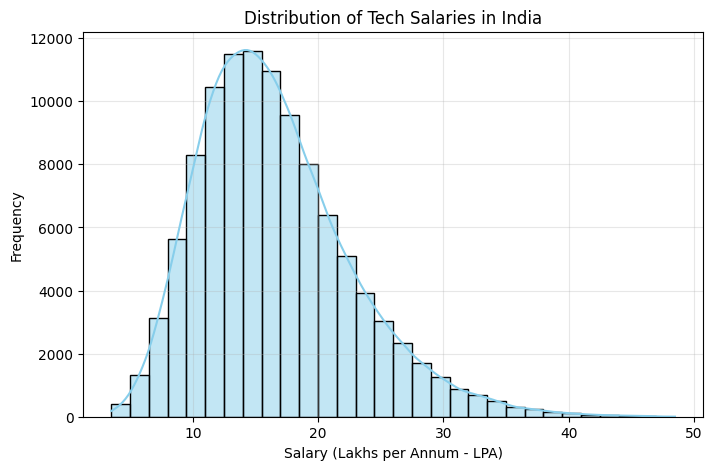

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary_LPA'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Tech Salaries in India')
plt.xlabel('Salary (Lakhs per Annum - LPA)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

### Plot 2: Salary Growth by Experience

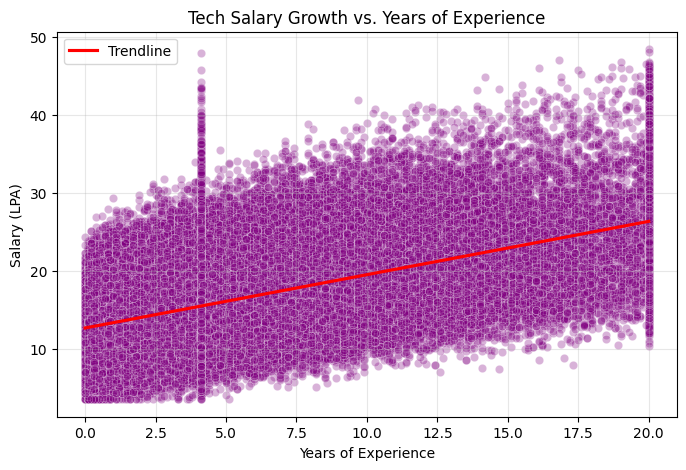

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Experience_Years', y='Salary_LPA', data=df, alpha=0.3, color='purple')
sns.regplot(x='Experience_Years', y='Salary_LPA', data=df, scatter=False, color='red', label='Trendline')
plt.title('Tech Salary Growth vs. Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (LPA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Plot 3: Salary Ranges by Job Title (AI/ML Premium)

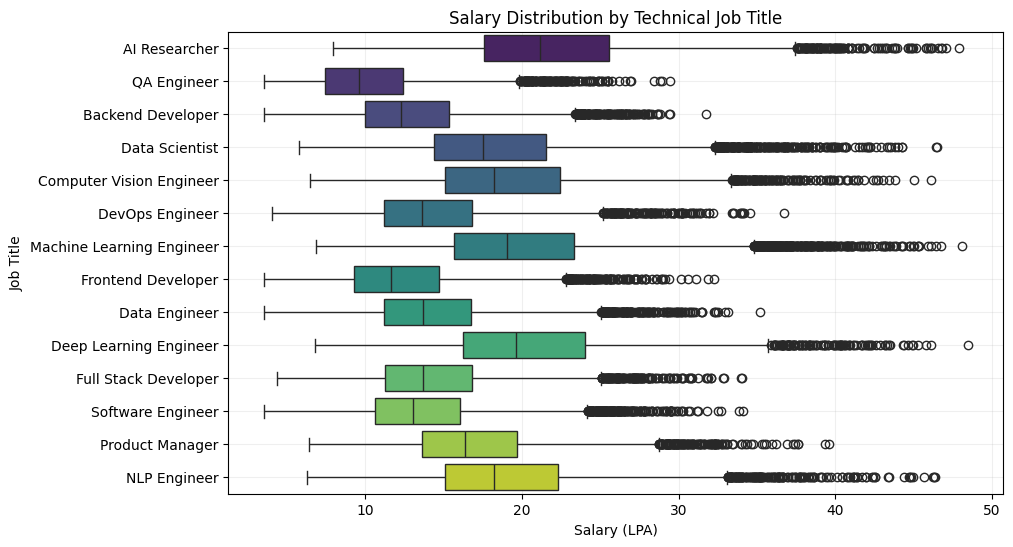

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Salary_LPA', y='Job_Title', data=df, palette='viridis', hue='Job_Title', legend=False)
plt.title('Salary Distribution by Technical Job Title')
plt.xlabel('Salary (LPA)')
plt.ylabel('Job Title')
plt.grid(True, alpha=0.2)
plt.show()

### Plot 4: Average Salary by Location

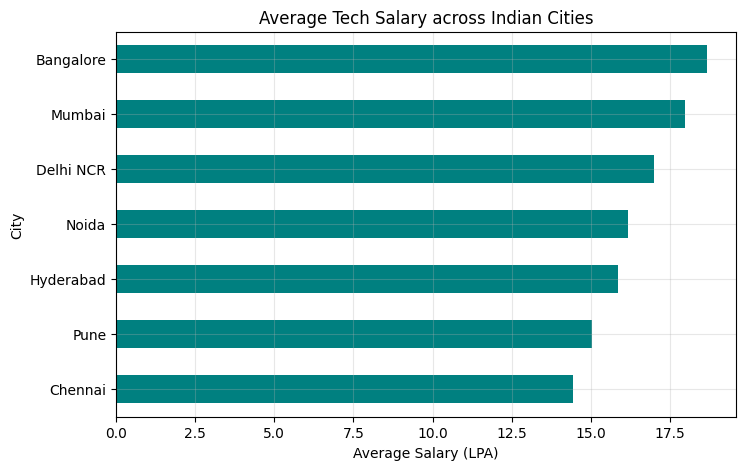

In [9]:
plt.figure(figsize=(8, 5))
df.groupby('Location')['Salary_LPA'].mean().sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Average Tech Salary across Indian Cities')
plt.xlabel('Average Salary (LPA)')
plt.ylabel('City')
plt.grid(True, alpha=0.3)
plt.show()

### Plot 5: Salary Ranges by Education Level

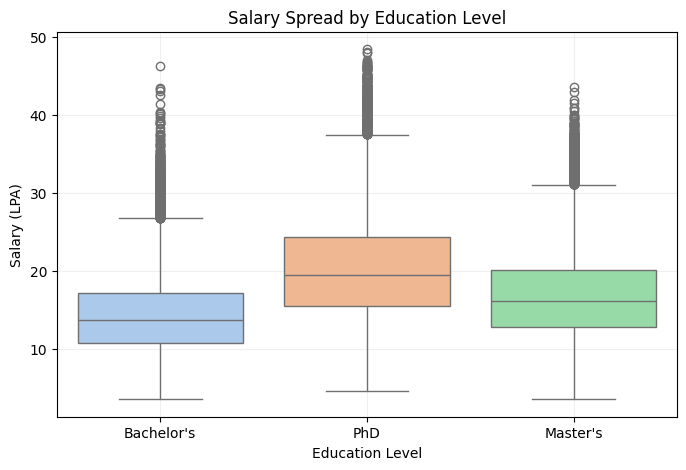

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Education_Level', y='Salary_LPA', data=df, palette='pastel', hue='Education_Level', legend=False)
plt.title('Salary Spread by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Salary (LPA)')
plt.grid(True, alpha=0.2)
plt.show()

### Plot 6: Most Common Technical Skills

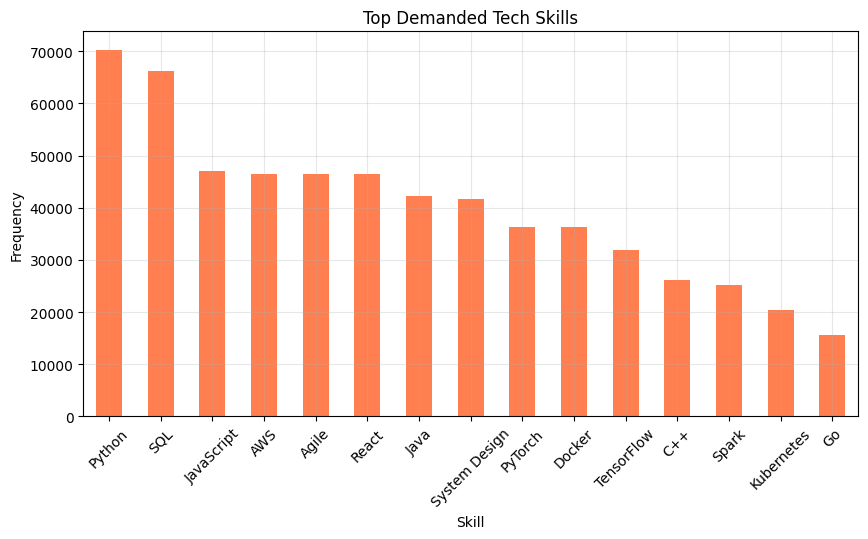

In [11]:
# Parse comma-separated skills to build frequency plot
skills_list = []
for s in df['Skills'].dropna():
    for item in s.split(','):
        skills_list.append(item.strip())

skills_series = pd.Series(skills_list)
plt.figure(figsize=(10, 5))
skills_series.value_counts().plot(kind='bar', color='coral')
plt.title('Top Demanded Tech Skills')
plt.xlabel('Skill')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()